In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [171]:
x = np.load('/content/data/X.npy')
y = np.load('/content/data/y.npy')

In [172]:
x.shape

(5000, 400)

In [173]:
y.shape

(5000, 1)

In [174]:
x[0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

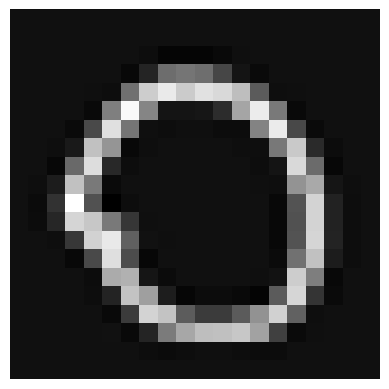

In [175]:
# see the image from specifix index
image = x[7].reshape((20, 20))

plt.imshow(image, cmap = 'gray')
plt.axis('off')
plt.show()

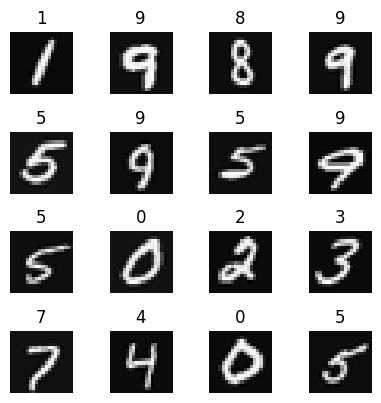

In [176]:
# let's say we want to see 16 sample randomly
m, n = x.shape

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
fig.tight_layout(pad = 0.1)

for i, ax in enumerate(axes.flat):
  # select a random index
  random_idx = np.random.randint(m)
  # print(random_idx)

  # select rows corresponding to the random indices and reshape the image
  image = x[random_idx].reshape((20, 20)).T

  ax.imshow(image, cmap='gray')

  # display the label above image
  ax.set_title(y[random_idx, 0])
  ax.set_axis_off()


In [177]:
# for binary classification, lets took only those example where label = 0 or 1
binary = []

for i in range(y.shape[0]):
  if (y[i] == 0 or y[i] == 1):
    binary.append(i)

len(binary)

1000

In [178]:
y = [y[binary[i]] for i in range(len(binary))]

In [179]:
y = np.array(y)

In [180]:
y.shape

(1000, 1)

In [181]:
x = [x[binary[i]] for i in range(len(binary))]

In [182]:
x = np.array(x)

In [183]:
x.shape

(1000, 400)

588
280
937
966
296
277
335
903
518
353
922
982
538
260
889
251


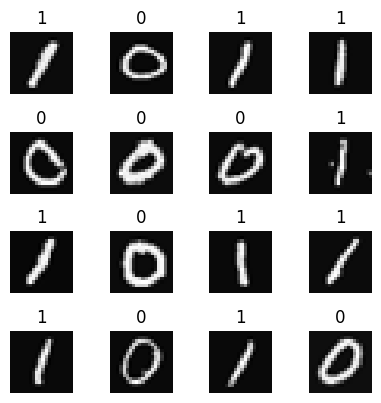

In [184]:
# let's say we want to see 16 sample randomly
m, n = x.shape

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
fig.tight_layout(pad = 0.1)

for i, ax in enumerate(axes.flat):
  # select a random index
  random_idx = np.random.randint(m)
  print(random_idx)

  # select rows corresponding to the random indices and reshape the image
  image = x[random_idx].reshape((20, 20)).T

  ax.imshow(image, cmap='gray')

  # display the label above image
  ax.set_title(y[random_idx, 0])
  ax.set_axis_off()

In [185]:
def sigmoid(z):

  return 1.0 / (1 + np.exp(-z))

In [186]:
def relu(z):

  return np.maximum(0, z)

In [187]:
def linear(z):
  return z

In [188]:
# this dense function works for only one sample
def dense(a_in, w, b, g):
  u = w.shape[1] # number of neurons
  a_out = np.zeros(u, )

  for i in range(u):
    z_i = np.dot(w[:, i], a_in) + b[i]

    if (g == 'sigmoid'):
      a_out[i] = sigmoid(z_i)
    elif (g == 'relu'):
      a_out[i] = relu(z_i)
    else:
      a_out[i] = linear(z_i)

  return a_out

In [189]:
# vectorize dense so that it can work with all the samples
def dense2 (a_in, w, b, g):
  z = np.dot(a_in, w) + b

  if (g == 'sigmoid'):
    return sigmoid(z)
  elif (g == 'relu'):
    return relu(z)
  else:
    return linear(z)

In [190]:
# parameter initialization
w1 = np.random.randn(10000).reshape((400, 25))
b1 = np.random.randn(25)

print(w1.shape, b1.shape)

(400, 25) (25,)


In [191]:
w2 = np.random.randn(375).reshape((25, 15))
b2 = np.random.randn(15)

print(w2.shape, b2.shape)

(25, 15) (15,)


In [192]:
w3 = np.random.randn(15).reshape((15, 1))
b3 = np.random.randn(1)

print(w3.shape, b3.shape)

(15, 1) (1,)


In [193]:
x.shape

(1000, 400)

In [194]:
a = dense(x[0], w1, b1, 'sigmoid')
a.shape

(25,)

In [195]:
a = dense2(x, w1, b1, 'sigmoid')
a.shape

(1000, 25)

In [196]:
a1 = dense2(x, w1, b1, 'sigmoid')
a1.shape

(1000, 25)

In [197]:
a2 = dense2(a1, w2, b2, 'relu')
a2.shape

(1000, 15)

In [198]:
a3 = dense2(a2, w3, b3, 'sigmoid')
a3.shape

(1000, 1)

In [199]:
yhat = np.zeros(a3.shape[0])

for i in range(a3.shape[0]):
  if (a3[i] >= 0.5):
    yhat[i] = 1
  else:
    yhat[i] = 0

In [205]:
correct = np.sum(yhat == y)
accuracy = correct / len(y)
print(f"Accuracy: {accuracy}")

Accuracy: 0.512


In [201]:
# this is ok, since we're making predictions only without doing any training task

In [202]:
## little bit optimisation in coding for clarity
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = dense2(x,  W1, b1, sigmoid)
    a2 = dense2(a1, W2, b2, sigmoid)
    a3 = dense2(a2, W3, b3, sigmoid)
    return a3

In [203]:
a3 = my_sequential(x, w1, b1, w2, b2, w3, b3)
a3.shape

(1000, 1)

In [204]:
# Vectorized thresholding
yhat = (a3 >= 0.5).astype(int)

# Vectorized accuracy
accuracy = np.mean(yhat == y)

print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.5120
